In [1]:
! pip install -U langgraph

  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.0
    Uninstalling langgraph-1.2.0:
      Successfully uninstalled langgraph-1.2.0


In [4]:
from langchain_core.messages import AnyMessage, AIMessage
from typing_extensions import TypedDict

class State(TypedDict):
  messages: list[AnyMessage]
  extra_field: int

def node(state: State):
   messages = state["messages"]
   new_message = AIMessage("你好")

   return {"messages": messages + [new_message], "extra_field": 10}

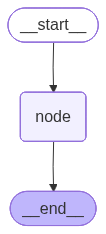

In [5]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)
graph_builder.add_node(node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()


from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
from langchain_core.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage("Hi")]})
for message in result["messages"]:
  message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

你好


In [ ]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import START, StateGraph

class State(TypedDict):
  value1: str
  value2: int

def step_1(state: State):
  return {"value1": "a"}

def step_2(state: State):
  current_val1 = state["value1"] 
  return {"value1": f"{current_val1}b"}

def step_3(state: State):
  return {"value2": 10}


graph_builder = StateGraph(State)
graph_builder.add_node("step_1", step_1)
graph_builder.add_node("step_2", step_2)
graph_builder.add_node("step_3", step_3)

graph_builder.add_edge(START, "step_1") 
graph_builder.add_edge("step_1", "step_2")
graph_builder.add_edge("step_2", "step_3")

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

TypeError: StateGraph.add_edge() missing 1 required positional argument: 'end_key'

In [10]:
graph.invoke({"value1": "c"})

{'value1': 'ab', 'value2': 10}

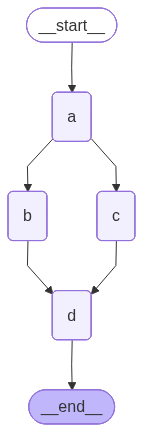

In [12]:
import operator
from typing import Annotated
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display



class State(TypedDict):
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}


def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}


def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
graph.invoke({"aggregate": []}, {"configurable": {"thread_id": "foo"}})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "D" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

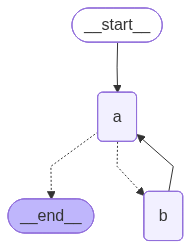

In [20]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]


def a(state: State):
    print(f'Node A sees {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Node B sees {state["aggregate"]}')
    return {"aggregate": ["B"]}


# Define nodes
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)


# Define edges
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END


builder.add_edge(START, "a")
builder.add_conditional_edges("a", route)
builder.add_edge("b", "a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
graph.invoke({"aggregate": []})

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B']
Node B sees ['A', 'B', 'A', 'B', 'A']
Node A sees ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

In [22]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({"aggregate": []}, {"recursion_limit": 4})
except GraphRecursionError:
    print("Recursion Error")

Node A sees []
Node B sees ['A']
Node A sees ['A', 'B']
Node B sees ['A', 'B', 'A']
Recursion Error


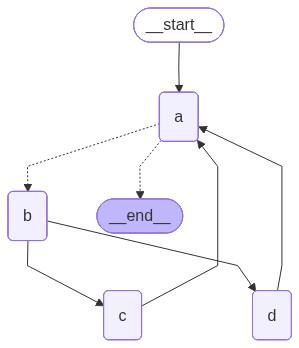

In [23]:
import operator
from typing import Annotated, Literal

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    aggregate: Annotated[list, operator.add]


def a(state: State):
    print(f'Node A sees {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Node B sees {state["aggregate"]}')
    return {"aggregate": ["B"]}


def c(state: State):
    print(f'Node C sees {state["aggregate"]}')
    return {"aggregate": ["C"]}


def d(state: State):
    print(f'Node D sees {state["aggregate"]}')
    return {"aggregate": ["D"]}


# 节点
builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)


# 边
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END


builder.add_edge(START, "a")
builder.add_conditional_edges("a", route)
builder.add_edge("b", "c")
builder.add_edge("b", "d")
builder.add_edge(["c", "d"], "a")
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
result = graph.invoke({"aggregate": []})

Node A sees []
Node B sees ['A']
Node C sees ['A', 'B']
Node D sees ['A', 'B']
Node A sees ['A', 'B', 'C', 'D']
Node B sees ['A', 'B', 'C', 'D', 'A']
Node C sees ['A', 'B', 'C', 'D', 'A', 'B']
Node D sees ['A', 'B', 'C', 'D', 'A', 'B']
Node A sees ['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


In [ ]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import END, StateGraph, START

load_dotenv()  


model1 = ChatOpenAI(
    temperature=0,
    model="mimo-v2.5-pro",
    api_key=os.environ["XIAOMI_API_KEY"],
    base_url="https://token-plan-cn.xiaomimimo.com/v1",
)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_API_BASE"],
)

# 定义要切换的模型
models = {
    "deepseek": model,
    "openai": model1,
}


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]


def _call_model(state: AgentState, config: RunnableConfig):
    # 使用LCEL的配置
    model_name = config["configurable"].get("model", "deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages": [response]}


# Define a new graph
builder = StateGraph(AgentState)
builder.add_node("model", _call_model)
builder.add_edge(START, "model")
builder.add_edge("model", END)

graph = builder.compile()

In [32]:
graph.invoke({"messages": [HumanMessage(content="hi 你是谁？")]})

{'messages': [HumanMessage(content='hi 你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！我是DeepSeek，由深度求索公司创造的AI助手。我是一个纯文本模型，能够回答各种问题，帮你处理文档、阅读链接等。我目前是免费使用的，知识截止时间是2025年5月。\n\n虽然我不支持多模态识别（比如直接“看懂”图片内容），但可以上传图片、PDF、Word、Excel等文件，我会从中读取文字信息来帮助你。我还支持联网搜索（需要你手动开启）、语音输入（App端），而且上下文处理能力超强，能一次性处理像《三体》三部曲那么大体量的内容！\n\n有什么我可以帮你的吗？😊', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户问“你是谁”，这是一个非常基础的自我介绍问题。用户可能是第一次接触我，想了解我的身份和基本功能。\n\n我需要直接、清晰地介绍自己是谁、由谁开发、以及能提供什么帮助。想到了用“你好！我是DeepSeek”开头，然后说明创造者，再列举几个核心特点，比如免费、知识截止时间、文件处理能力等，让用户快速建立认知。最后用友好的语气询问是否需要帮助，开启对话。\n\n嗯，回复结构就这样：问候和身份声明、创造者信息、几个关键功能点、主动提供帮助的邀请。保持热情和实用的语气。'}, response_metadata={'token_usage': {'completion_tokens': 261, 'prompt_tokens': 8, 'total_tokens': 269, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 129, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0

In [33]:
config = {"configurable": {"model": "openai"}}
graph.invoke({"messages": [HumanMessage(content="hi 你是谁？")]}, config=config)

{'messages': [HumanMessage(content='hi 你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！😊\n\n我是 **MiMo-v2.5-pro**，一个由**小米 MiMo 团队**开发的 AI 助手。\n\n我拥有 1T 参数和 1M-token 的上下文窗口，可以帮你处理各种问题和任务，比如：\n\n- 💬 日常聊天和问答\n- 📝 文本创作和写作\n- 💻 编程和技术问题\n- 📚 知识查询和学习\n- 🤔 分析和推理\n\n有什么我可以帮你的吗？很高兴认识你！', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 246, 'prompt_tokens': 256, 'total_tokens': 502, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 127, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 192}}, 'model_provider': 'openai', 'model_name': 'mimo-v2.5-pro', 'system_fingerprint': None, 'id': '584129f4b18f47318128d6ad1d6d6af1', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e72ff-35d2-7253-86e2-ed41a77dc889-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 256, 'output_tokens': 246, 'total_t

In [38]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.types import Send
from langgraph.graph import END, StateGraph, START

from pydantic import BaseModel, Field


# 模型和提示词
# 定义我们将使用的模型和提示词
subjects_prompt = """生成一个逗号分隔的列表，包含2到5个与以下主题相关的例子：{topic}。"""
joke_prompt = """生成一个关于{subject}的笑话"""
best_joke_prompt = """以下是一些关于{topic}的笑话。选出最好的一个！返回最佳笑话的ID。

{jokes}"""


model = ChatOpenAI(
    temperature=0,
    model="mimo-v2.5-pro",
    api_key=os.environ["XIAOMI_API_KEY"],
    base_url="https://token-plan-cn.xiaomimimo.com/v1",
)


class Subjects(BaseModel):
    subjects: list[str] = Field(description="2到5个与主题相关的例子列表")


class Joke(BaseModel):
    joke: str = Field(description="关于给定主题的一个笑话")


class BestJoke(BaseModel):
    id: int = Field(description="最佳笑话的索引，从0开始", ge=0)


def structured(schema):
    # MiMo 默认 structured output 字段名不稳定，用 function_calling
    return model.with_structured_output(schema, method="function_calling")

# 这将是主图的整体状态。
# 它将包含一个主题（我们期望用户提供）
# 然后将生成一个主题列表，并为每个主题生成一个笑话
class OverallState(TypedDict):
    topic: str
    subjects: list
    # 注意这里我们使用operator.add
    # 这是因为我们想把从各个节点生成的所有笑话
    # 合并回一个列表 - 这本质上是"归约"部分
    jokes: Annotated[list, operator.add]
    best_selected_joke: str


# 这将是我们将"映射"所有主题的节点的状态
# 用于生成笑话
class JokeState(TypedDict):
    subject: str


# 这是我们用来生成笑话主题的函数
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = structured(Subjects).invoke(prompt)
    return {"subjects": response.subjects}


# 这里我们根据给定的主题生成笑话
def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = structured(Joke).invoke(prompt)
    return {"jokes": [response.joke]}


# 这里我们定义映射到生成的主题上的逻辑
# 我们将在图中使用这个作为边缘
def continue_to_jokes(state: OverallState):
    # 我们将返回一个`Send`对象列表
    # 每个`Send`对象包含图中节点的名称
    # 以及要发送到该节点的状态
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]


# 这里我们将评判最佳笑话
def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = structured(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}


# 构建图：这里我们将所有内容组合在一起构建我们的图
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)
app = graph.compile()

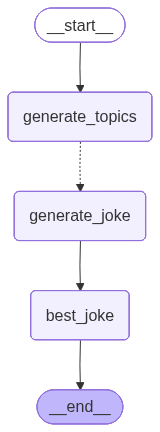

In [39]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [40]:
for s in app.stream({"topic": "动物"}):
    print(s)

{'generate_topics': {'subjects': ['猫', '狗', '大象', '熊猫', '海豚']}}
{'generate_joke': {'jokes': ['为什么海豚从来不分享秘密？因为它们总是把一切都"海"吐出来！']}}
{'generate_joke': {'jokes': ['为什么大象不用电脑？因为它害怕鼠标！']}}
{'generate_joke': {'jokes': ['为什么猫总是喜欢坐在电脑键盘上？因为它们想要在互联网上找到更多的“猫片”！']}}
{'generate_joke': {'jokes': ['主人问狗狗："你最爱谁？"狗狗摇了摇尾巴说："当然是你啊！"主人又问："那如果我和肉骨头同时掉进水里，你先救谁？"狗狗沉默了一会儿，认真地说："我会先把肉骨头叼上岸，然后……再把你叼上岸。"主人大为感动："没想到我在你心里比肉骨头还重要！"狗狗害羞地低下头："不是啦，是因为肉骨头比你轻……"']}}
{'generate_joke': {'jokes': ['为什么熊猫总是有黑眼圈？因为它每天晚上都熬夜数星星——一颗、两颗、三颗……数到天亮就变成黑眼圈啦！']}}
{'best_joke': {'best_selected_joke': '为什么猫总是喜欢坐在电脑键盘上？因为它们想要在互联网上找到更多的“猫片”！'}}
